# İstanbul Kiralık Ev Tahmini- Web Scrapping - Regression

##### İnternetten İstanbul'daki kiralık daire fiyatlarını çekerek fiyat tahmini modeli

#### Import packages

In [ ]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import numpy as np
import time
import random
import warnings
warnings.filterwarnings('ignore')

### Web Scrapping Codes

###### Web Scrapping kodlarını satır içi yorum haline getirdim, inline commentleri kaldırmak için ctrl + a yaparak satırdaki tüm kodları seçip ctrl + / tuşuna basarak kaldırabilirsiniz

In [ ]:
# headers = {"User-Agent": "Mozilla/5.0"}

In [ ]:
# base_url = "https://www.emlakjet.com/kiralik-daire/istanbul/"
# page=[f"{base_url}{i}" for i in range(1,49)]

# print(page)

In [ ]:
# # Kiralık ev ilanlarının linklerini tutmak için boş bir liste oluşturuyoruz
# house = []

# # 1'den 44'e kadar tüm sayfaları sırayla ziyaret ediyoruz
# for url in page:
#     # Sayfaya tarayıcı gibi davranarak GET isteği gönderiyoruz
#     response = requests.get(url, headers=headers)

#     # Sayfa başarıyla yüklendiyse (HTTP 200 durumu)
#     if response.status_code == 200:
#         # Sayfa içeriğini BeautifulSoup ile HTML olarak parse ediyoruz
#         soup = BeautifulSoup(response.content, "html.parser")

#         # Sayfadaki tüm ilan kutularını (listingleri) seçiyoruz
#         listings = soup.find_all("div", class_="styles_listingWrapper__I0H_l")

#         # Her bir ilan kutusunu tek tek inceliyoruz
#         for listing in listings:
#             # Eğer ilan kutusu "Aramayı Kaydet" butonunu içeriyorsa, geçiyoruz
#             if listing.find("div", class_="styles_saveSeasrchWrapper__gdgdi"):
#                 continue
#             # Eğer ilan kutusu başka bir kapsayıcıysa (örneğin önerilen kutular), geçiyoruz
#             elif listing.find("div", class_="styles_container__6p6oI"):
#                 continue
#             # Eğer ilan kutusu reklam slotuysa, yine geçiyoruz
#             elif listing.find("div", class_="styles_adSlotWrap__ARrCX"):
#                 continue

#             # İlan bağlantısını (linkini) içeren <a> etiketi bulunuyor
#             link_tag = listing.find("a", href=True)

#             # Eğer geçerli bir bağlantı etiketi varsa
#             if link_tag:
#                 # Bağlantının başına domain ekleyerek tam bağlantı oluşturuyoruz
#                 full_link = "https://www.emlakjet.com/" + link_tag["href"]

#                 # Bağlantıyı house listesine ekliyoruz
#                 house.append(full_link)

In [ ]:
# import pandas as pd
# import numpy as np

# # Tüm ev ilanlarının detaylarını tutacağımız boş bir liste
# house_data = []

# # Daha önce elde ettiğimiz tüm ilan bağlantılarını tek tek dolaşıyoruz
# for house_url in house:
#     # Her ilan linkine GET isteği gönderiyoruz (headers ile tarayıcı gibi davranarak)
#     response = requests.get(house_url, headers=headers)

#     # Sayfa başarıyla yüklendiyse
#     if response.status_code == 200:
#         # Sayfa içeriğini BeautifulSoup ile HTML olarak parse ediyoruz
#         soup = BeautifulSoup(response.content, "html.parser")

#         # Her bir ev için özellikleri tutacağımız sözlük
#         house_info = {}

#         # Fiyat bilgisini içeren <span> etiketini buluyoruz
#         price_span = soup.find("span", class_="styles_price__6zH_9")
#         # Fiyat varsa metnini al, yoksa np.nan ata
#         price = price_span.get_text(strip=True) if price_span else np.nan

#         # Konum bilgisini içeren <span> etiketini buluyoruz
#         location_span = soup.find("span", class_="styles_location__Y01SC")
#         if location_span:
#             # Metni al ve "-" işaretine göre parçala (örneğin: "Türkiye - Denizli - Pamukkale")
#             location_text = location_span.get_text(strip=True)
#             location_parts = location_text.split("-")
#             # İlçe ve mahalle bilgisini birleştirerek al (örneğin: "Pamukkale - Mehmetçik Mahallesi")
#             location = "-".join(location_parts[1:3]) if len(location_parts) >= 2 else np.nan
#         else:
#             # Konum bulunamazsa boş (nan) olarak geç
#             location = np.nan

#         # Özelliklerin (m², oda sayısı, bina yaşı vs.) yer aldığı bölümü bul
#         features_div = soup.find("div", class_="styles_inner__sV8Bk")

#         if features_div:
#             # İçindeki <li> etiketlerini (özellikleri) bul
#             li_tags = features_div.find_all("li")

#             # Her bir özellik için
#             for li in li_tags:
#                 # İçindeki <span> etiketlerini bul (genellikle 2 tane: başlık ve değer)
#                 spans = li.find_all("span")
#                 if len(spans) == 2:
#                     # Anahtar ve değeri ayıkla ve temizle
#                     key = spans[0].get_text(strip=True)
#                     value = spans[1].get_text(strip=True)
#                     # Sözlüğe ekle (örneğin: "Brüt m²": "120")
#                     house_info[key] = value

#             # Fiyat, konum ve linki de sözlüğe ekliyoruz
#             house_info["Price"] = price
#             house_info["Location"] = location
#             house_info["link"] = house_url

#             # Bu evin tüm bilgilerini ana listeye ekliyoruz
#             house_data.append(house_info)


In [ ]:
# df = pd.DataFrame(house_data)

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows",200)

In [ ]:
# df.to_csv("İstanbul_kiralıkEv_data.csv")

In [ ]:
df1 = pd.read_csv("İstanbul_kiralıkEv_data.csv")

In [ ]:
df = df1.copy()

### Exploratory Data Analysis - Data Imputation - Feature Engineering

In [ ]:
df.head()

,Unnamed: 0,İlan Numarası,İlan Oluşturma Tarihi,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Kullanım Durumu,Aidat,Tapu Durumu,Site İçerisinde,Depozito,Banyo Sayısı,Banyo Metrekare,Balkon Durumu,Balkon Sayısı,Balkon Tipi,Balkon Metrekare,WC Sayısı,WC Metrekare,Fiyat Durumu,Ada,Parsel,Price,Location,link,Yapı Durumu,Yapı Tipi,Eşya Durumu,Takas,Görüntülü Gezilebilir mi?,Salon Metrekare
0,0,17105914,03 Nisan 2025,03 Nisan 2025,Konut,Kiralık,Daire,90 m²,110 m²,2+1,21 Ve Üzeri,3.Kat,5,Kombi Doğalgaz,Kiracı Oturuyor,150 TL,Arsa Tapulu,Hayır,18000 TL,1,3 m²,Var,1,Kapalı Balkon,3 m²,1.00,1 m²,Genel Fiyat,NaN,3173,18.000TL,Esenler - Fevzi Çakmak Mahallesi,https://www.emlakjet.com//ilan/esenler-fevzica...,NaN,NaN,NaN,NaN,NaN,NaN
1,1,17104186,03 Nisan 2025,03 Nisan 2025,Konut,Kiralık,Daire,70 m²,80 m²,2+1,11-15,Yüksek Giriş,4,Kombi Doğalgaz,Boş,350 TL,Tapu Kaydı Yok,Hayır,16000 TL,1,NaN,Var,1,NaN,NaN,NaN,NaN,Genel Fiyat,NaN,NaN,16.000TL,Bayrampaşa - Cevatpaşa Mahallesi,https://www.emlakjet.com//ilan/umur-gayrimenku...,NaN,NaN,NaN,NaN,NaN,NaN
2,2,17103363,03 Nisan 2025,04 Nisan 2025,Konut,Kiralık,Daire,70 m²,75 m²,2+1,16-20,Yüksek Giriş,5,Doğalgaz Sobalı,Boş,100 TL,Tapu Kaydı Yok,Hayır,14000 TL,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Genel Fiyat,NaN,NaN,14.000TL,Sultangazi - Uğur Mumcu Mahallesi,https://www.emlakjet.com//ilan/kiralik-yuksek-...,NaN,NaN,NaN,NaN,NaN,NaN
3,3,17090071,29 Mart 2025,04 Nisan 2025,Konut,Kiralık,Daire,90 m²,95 m²,2+1,21 Ve Üzeri,1.Kat,5,Kombi Doğalgaz,Boş,100 TL,Tapu Kaydı Yok,Hayır,17500 TL,1,NaN,Var,NaN,NaN,NaN,NaN,NaN,Genel Fiyat,NaN,NaN,17.500TL,Sultangazi - Cebeci Mahallesi,https://www.emlakjet.com//ilan/kiralik-daire-s...,NaN,NaN,NaN,NaN,NaN,NaN
4,4,17055559,21 Mart 2025,21 Mart 2025,Konut,Kiralık,Daire,65 m²,75 m²,2+1,0 (Yeni),3.Kat,5,Kombi Doğalgaz,Boş,NaN,Kat İrtifakı,Hayır,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Genel Fiyat,NaN,8136,30.000TL,Bahçelievler - Hürriyet Mahallesi,https://www.emlakjet.com//ilan/hurriyet-mahall...,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(1200, 39)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 1200 non-null   int64  
 1   İlan Numarası              1200 non-null   int64  
 2   İlan Oluşturma Tarihi      1200 non-null   object 
 3   İlan Güncelleme Tarihi     1200 non-null   object 
 4   Türü                       1200 non-null   object 
 5   Kategorisi                 1200 non-null   object 
 6   Tipi                       1200 non-null   object 
 7   Net Metrekare              1200 non-null   object 
 8   Brüt Metrekare             1200 non-null   object 
 9   Oda Sayısı                 1200 non-null   object 
 10  Binanın Yaşı               1200 non-null   object 
 11  Bulunduğu Kat              1200 non-null   object 
 12  Binanın Kat Sayısı         1200 non-null   int64  
 13  Isıtma Tipi                1200 non-null   objec

In [ ]:
df.value_counts("Tipi")

,count
Tipi,
Daire,1200


In [ ]:
df.value_counts("Isıtma Tipi")

,count
Isıtma Tipi,
Kombi Doğalgaz,923
Merkezi (Pay Ölçer),147
Merkezi Doğalgaz,55
Yerden Isıtma,22
Doğalgaz Sobalı,20
Sobalı,11
Klimalı,9
Isıtma Yok,7
Kat Kaloriferi,2


In [ ]:
df.value_counts("Yapı Tipi")

,count
Yapı Tipi,
Betonarme,253
Ahşap,2
Kagir,2
Taş Bina,2
Yığma,1
Çelik,1


In [ ]:
df.value_counts("Yapı Durumu")

,count
Yapı Durumu,
İkinci El,264
Sıfır,36


In [ ]:
df.value_counts("Balkon Tipi")

,count
Balkon Tipi,
Açık Balkon,100
Kapalı Balkon,36
Açık Teras,16
"Açık Balkon, Kapalı Balkon",9
"Açık Balkon, Açık Teras",3
Fransız Balkon,3
"Açık Balkon, Açık Teras, Kapalı Teras",1
"Açık Teras, Kapalı Balkon",1
"Açık Balkon, Kapalı Teras",1


In [ ]:
df.value_counts("Kullanım Durumu")

,count
Kullanım Durumu,
Boş,1148
Kiracı Oturuyor,34
Mülk Sahibi Oturuyor,18


In [ ]:
df.value_counts("Eşya Durumu")

,count
Eşya Durumu,
Boş,575
Eşyalı,208


In [ ]:
df.value_counts("Site İçerisinde")

,count
Site İçerisinde,
Hayır,918
Evet,282


In [ ]:
df.value_counts("Fiyat Durumu")

,count
Fiyat Durumu,
Genel Fiyat,1171
Birim Fiyat,29


In [ ]:
df[(df["Fiyat Durumu"] == "Birim Fiyat")].head(3)

,Unnamed: 0,İlan Numarası,İlan Oluşturma Tarihi,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Kullanım Durumu,Aidat,Tapu Durumu,Site İçerisinde,Depozito,Banyo Sayısı,Banyo Metrekare,Balkon Durumu,Balkon Sayısı,Balkon Tipi,Balkon Metrekare,WC Sayısı,WC Metrekare,Fiyat Durumu,Ada,Parsel,Price,Location,link,Yapı Durumu,Yapı Tipi,Eşya Durumu,Takas,Görüntülü Gezilebilir mi?,Salon Metrekare
44,44,17112869,04 Nisan 2025,04 Nisan 2025,Konut,Kiralık,Daire,50 m²,60 m²,2+1,21 Ve Üzeri,Bahçe Katı,4,Kombi Doğalgaz,Boş,NaN,Kat İrtifakı,Hayır,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Birim Fiyat,1911.00,12,17.000TL,Fatih - Balat Mahallesi,https://www.emlakjet.com//ilan/sahibinden-merk...,NaN,NaN,NaN,NaN,NaN,NaN
61,61,17111912,04 Nisan 2025,04 Nisan 2025,Konut,Kiralık,Daire,70 m²,75 m²,2+1,16-20,4.Kat,8,Kombi Doğalgaz,Boş,200 TL,Hisseli Tapu,Hayır,20000 TL,1,12 m²,Var,1,Kapalı Balkon,7 m²,1.00,NaN,Birim Fiyat,9160.00,2,19.000TL,Şişli - Gülbahar Mahallesi,https://www.emlakjet.com//ilan/sahibinden-kira...,İkinci El,Betonarme,Boş,Yok,Evet,30 m²
187,187,17105698,03 Nisan 2025,03 Nisan 2025,Konut,Kiralık,Daire,85 m²,90 m²,2+1,5-10,Bahçe Katı,4,Kombi Doğalgaz,Boş,NaN,Yabancıdan,Evet,NaN,1,NaN,Yok,NaN,NaN,NaN,NaN,NaN,Birim Fiyat,NaN,NaN,18.000TL,Beylikdüzü - Sahil Mahallesi,https://www.emlakjet.com//ilan/kavakli-sahil-b...,NaN,NaN,Boş,NaN,NaN,NaN


In [ ]:
df.value_counts("Location")

,count
Location,
Sultangazi - Cebeci Mahallesi,20
Bahçelievler - Şirinevler Mahallesi,17
Pendik - Yenişehir Mahallesi,14
Beylikdüzü - Adnan Kahveci Mahallesi,13
Avcılar - Gümüşpala Mahallesi,13
...,...
Ümraniye - Atakent Mahallesi,1
Ümraniye - Elmalıkent Mahallesi,1
Ümraniye - Tantavi Mahallesi,1


In [ ]:
df.value_counts("Parsel")

,count
Parsel,
1,34
2,25
5,20
4,16
6,14
7,11
9,11
11,11
12,9


In [ ]:
df.value_counts("Oda Sayısı")

,count
Oda Sayısı,
2+1,613
3+1,248
1+1,241
4+1,27
Stüdyo,25
1.5+1,6
4+2,6
1 Oda,5
5+1,5


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
İlan Numarası,0
İlan Oluşturma Tarihi,0
İlan Güncelleme Tarihi,0
Türü,0
Kategorisi,0
Tipi,0
Net Metrekare,0
Brüt Metrekare,0
Oda Sayısı,0


In [ ]:
# Önemsiz, tekrarlanabilir, çok fazla boş veri içeren sütunları kaldırıyoruz
df.drop(["İlan Oluşturma Tarihi","Türü","Kategorisi","Brüt Metrekare",
         "Kullanım Durumu","Takas","Fiyat Durumu","link",
         "Aidat","Balkon Durumu","Görüntülü Gezilebilir mi?","Ada",
         "Parsel","Yapı Tipi","Banyo Metrekare",
         "Balkon Metrekare","Salon Metrekare","WC Metrekare"], axis=1, inplace=True)

In [ ]:
df.head()

,Unnamed: 0,İlan Numarası,İlan Güncelleme Tarihi,Tipi,Net Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Tapu Durumu,Site İçerisinde,Depozito,Banyo Sayısı,Balkon Sayısı,Balkon Tipi,WC Sayısı,Price,Location,Yapı Durumu,Eşya Durumu
0,0,17105914,03 Nisan 2025,Daire,90 m²,2+1,21 Ve Üzeri,3.Kat,5,Kombi Doğalgaz,Arsa Tapulu,Hayır,18000 TL,1,1,Kapalı Balkon,1.00,18.000TL,Esenler - Fevzi Çakmak Mahallesi,NaN,NaN
1,1,17104186,03 Nisan 2025,Daire,70 m²,2+1,11-15,Yüksek Giriş,4,Kombi Doğalgaz,Tapu Kaydı Yok,Hayır,16000 TL,1,1,NaN,NaN,16.000TL,Bayrampaşa - Cevatpaşa Mahallesi,NaN,NaN
2,2,17103363,04 Nisan 2025,Daire,70 m²,2+1,16-20,Yüksek Giriş,5,Doğalgaz Sobalı,Tapu Kaydı Yok,Hayır,14000 TL,1,NaN,NaN,NaN,14.000TL,Sultangazi - Uğur Mumcu Mahallesi,NaN,NaN
3,3,17090071,04 Nisan 2025,Daire,90 m²,2+1,21 Ve Üzeri,1.Kat,5,Kombi Doğalgaz,Tapu Kaydı Yok,Hayır,17500 TL,1,NaN,NaN,NaN,17.500TL,Sultangazi - Cebeci Mahallesi,NaN,NaN
4,4,17055559,21 Mart 2025,Daire,65 m²,2+1,0 (Yeni),3.Kat,5,Kombi Doğalgaz,Kat İrtifakı,Hayır,NaN,1,NaN,NaN,NaN,30.000TL,Bahçelievler - Hürriyet Mahallesi,NaN,NaN


In [ ]:
df.drop(["Yapı Durumu","Depozito"], axis=1, inplace=True)

In [ ]:
df.shape

(1200, 19)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
İlan Numarası,0
İlan Güncelleme Tarihi,0
Tipi,0
Net Metrekare,0
Oda Sayısı,0
Binanın Yaşı,0
Bulunduğu Kat,0
Binanın Kat Sayısı,0
Isıtma Tipi,0


In [ ]:
df.sample(4)

,Unnamed: 0,İlan Numarası,İlan Güncelleme Tarihi,Tipi,Net Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Balkon Sayısı,Balkon Tipi,WC Sayısı,Price,Location,Eşya Durumu
557,557,17084146,28 Mart 2025,Daire,66 m²,2+1,1,7.Kat,17,Merkezi (Pay Ölçer),Kat İrtifakı,Evet,1,NaN,NaN,NaN,39.000TL,Maltepe - Zümrütevler Mahallesi,Eşyalı
1063,1063,17052538,21 Mart 2025,Daire,75 m²,2+1,5-10,Yüksek Giriş,5,Kombi Doğalgaz,Kat Mülkiyeti,Hayır,1,NaN,NaN,NaN,26.000TL,Bahçelievler - Siyavuşpaşa Mahallesi,Eşyalı
849,849,17065038,24 Mart 2025,Daire,90 m²,2+1,0 (Yeni),Bahçe Katı,2,Yerden Isıtma,Yabancıdan,Evet,2,1,Açık Balkon,NaN,45.000TL,Başakşehir - Bahçeşehir 2. Kısım Mahallesi,NaN
173,173,17106237,04 Nisan 2025,Daire,60 m²,2+1,5-10,7.Kat,9,Merkezi (Pay Ölçer),Tapu Kaydı Yok,Evet,1,NaN,NaN,NaN,25.000TL,Başakşehir - Kayabaşı Mahallesi,Eşyalı


In [ ]:
# İlan Güncellenme Tarihinden kaç gün önce ilana çıkarıldığını buluyoruz
from datetime import datetime

today = datetime(2025, 4, 4)
month_map = {
    "Ocak": "January", "Şubat": "February", "Mart": "March",
    "Nisan": "April", "Mayıs": "May", "Haziran": "June",
    "Temmuz": "July", "Ağustos": "August", "Eylül": "September",
    "Ekim": "October", "Kasım": "November", "Aralık": "December"
}

dates_str = df["İlan Güncelleme Tarihi"]
df["İlandan sonra Geçen Gün"] = dates_str.replace(month_map, regex=True) \
    .apply(lambda x: (today - datetime.strptime(x, "%d %B %Y")).days)

df = df.drop(columns=["İlan Güncelleme Tarihi"])


In [ ]:
df = df.dropna(subset=["Net Metrekare"]) # Net Metrekare sütunu boş olan satırı siliyoruz

In [ ]:
#Net metrekaredeki m2 leri siliyoruz
df["Net Metrekare"] = df["Net Metrekare"].str.replace(" m²", "").astype(int)

In [ ]:
#binanın yaşı ilk değer hariç temizliyoruz
df["Binanın Yaşı"] = df["Binanın Yaşı"].str.extract(r"^(\d+)")
df["Binanın Yaşı"] = df["Binanın Yaşı"].astype(int)

In [ ]:
# Eksik (NaN) değerleri "Boş" ile dolduralım
df["Eşya Durumu"].fillna("Boş", inplace=True)

In [ ]:
# Kontrol edelim: kaç farklı değer var ve her birinden kaç tane var
df["Eşya Durumu"].value_counts()

,count
Eşya Durumu,
Boş,992
Eşyalı,208


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
İlan Numarası,0
Tipi,0
Net Metrekare,0
Oda Sayısı,0
Binanın Yaşı,0
Bulunduğu Kat,0
Binanın Kat Sayısı,0
Isıtma Tipi,0
Tapu Durumu,0


In [ ]:
df = df.dropna(subset=["Bulunduğu Kat"]) # bulunduğu kat sütunu boş olan satırı siliyoruz

In [ ]:
#Tapu durumu
df.value_counts("Tapu Durumu")

,count
Tapu Durumu,
Kat Mülkiyeti,584
Kat İrtifakı,207
Tapu Kaydı Yok,101
Bilinmiyor,85
Yabancıdan,62
Arsa Tapulu,59
Hisseli Tapu,48
Kooperatiften Tapu,47
Müstakil Tapulu,7


In [ ]:
# "Price" sütunundaki noktaları ve "TL" ifadelerini kaldırıp sayıya çevirelim
df["Price"] = df["Price"].str.replace(".", "", regex=False)  # Noktaları kaldır
df["Price"] = df["Price"].str.replace("TL", "", regex=False)  # TL ifadesini kaldır
df["Price"] = df["Price"].str.strip()  # Boşlukları temizle
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")  # Sayıya çevir

In [ ]:
df["Price"].sample(10)

,Price
882,15000
727,20000
805,40000
931,70000
1127,22000
464,20000
287,21500
182,17000
651,30000
890,28000


In [ ]:
# "Location" sütununu ilçe ve mahalle olarak ayıralım
df[["İlçe", "Mahalle"]] = df["Location"].str.split(" - ", n=1, expand=True)

# "Location" sütununu silelim
df.drop(columns=["Location"], inplace=True)

In [ ]:
df.sample(3)

,Unnamed: 0,İlan Numarası,Tipi,Net Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Balkon Sayısı,Balkon Tipi,WC Sayısı,Price,Eşya Durumu,İlandan sonra Geçen Gün,İlçe,Mahalle
40,40,17112903,Daire,85,2+1,21,1.Kat,2,Klimalı,Bilinmiyor,Hayır,1,NaN,NaN,NaN,20000,Boş,0,Kartal,Yakacık Çarşı Mahallesi
878,878,17062945,Daire,90,2+1,21,Çatı Katı,5,Doğalgaz Sobalı,Tapu Kaydı Yok,Hayır,1,1,Kapalı Teras,1.00,12000,Boş,9,Sultangazi,50. Yıl Mahallesi
355,355,17105141,Daire,80,2+1,5,Yüksek Giriş,4,Kombi Doğalgaz,Kat Mülkiyeti,Hayır,1,NaN,NaN,NaN,20000,Boş,1,Bağcılar,Yavuz Selim Mahallesi


In [ ]:
# "Balkon Sayısı" sütunundaki NaN değerleri 0 ile dolduralım
df["Balkon Sayısı"].fillna(0, inplace=True)

In [ ]:
df["Balkon Sayısı"] = pd.to_numeric(df["Balkon Sayısı"], errors="coerce").fillna(0).astype(int)

In [ ]:
df.value_counts("Balkon Tipi")

,count
Balkon Tipi,
Açık Balkon,100
Kapalı Balkon,36
Açık Teras,16
"Açık Balkon, Kapalı Balkon",9
"Açık Balkon, Açık Teras",3
Fransız Balkon,3
"Açık Balkon, Açık Teras, Kapalı Teras",1
"Açık Teras, Kapalı Balkon",1
"Açık Balkon, Kapalı Teras",1


In [ ]:
df[["Balkon Sayısı","Balkon Tipi"]].sample(7)

,Balkon Sayısı,Balkon Tipi
554,0,NaN
430,0,NaN
661,2,"Açık Balkon, Kapalı Balkon"
1005,0,NaN
17,0,NaN
1040,0,NaN
36,0,NaN


In [ ]:
# Koşullu doldurma işlemi: Balkon Tipi boş olanları Balkon Sayısına göre doldur
df.loc[(df["Balkon Tipi"].isna()) & (df["Balkon Sayısı"] == 0), "Balkon Tipi"] = "Yok"
df.loc[(df["Balkon Tipi"].isna()) & (df["Balkon Sayısı"] > 0), "Balkon Tipi"] = "Kapalı Balkon"

In [ ]:
df.value_counts("Balkon Tipi")

,count
Balkon Tipi,
Yok,997
Açık Balkon,100
Kapalı Balkon,67
Açık Teras,16
"Açık Balkon, Kapalı Balkon",9
"Açık Balkon, Açık Teras",3
Fransız Balkon,3
"Açık Balkon, Açık Teras, Kapalı Teras",1
"Açık Teras, Kapalı Balkon",1


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
İlan Numarası,0
Tipi,0
Net Metrekare,0
Oda Sayısı,0
Binanın Yaşı,0
Bulunduğu Kat,0
Binanın Kat Sayısı,0
Isıtma Tipi,0
Tapu Durumu,0


In [ ]:
# "WC Sayısı" sütunundaki boş (NaN) değerleri 1 ile doldur
df["WC Sayısı"].fillna(1, inplace=True)

# Sayıya çevirelim ve tipini kontrol edelim
df["WC Sayısı"] = pd.to_numeric(df["WC Sayısı"], errors="coerce").astype(int)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
İlan Numarası,0
Tipi,0
Net Metrekare,0
Oda Sayısı,0
Binanın Yaşı,0
Bulunduğu Kat,0
Binanın Kat Sayısı,0
Isıtma Tipi,0
Tapu Durumu,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               1200 non-null   int64 
 1   İlan Numarası            1200 non-null   int64 
 2   Tipi                     1200 non-null   object
 3   Net Metrekare            1200 non-null   int64 
 4   Oda Sayısı               1200 non-null   object
 5   Binanın Yaşı             1200 non-null   int64 
 6   Bulunduğu Kat            1200 non-null   object
 7   Binanın Kat Sayısı       1200 non-null   int64 
 8   Isıtma Tipi              1200 non-null   object
 9   Tapu Durumu              1200 non-null   object
 10  Site İçerisinde          1200 non-null   object
 11  Banyo Sayısı             1200 non-null   object
 12  Balkon Sayısı            1200 non-null   int64 
 13  Balkon Tipi              1200 non-null   object
 14  WC Sayısı                1200 non-null  

#### Data Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Fiyatların %99’lik çeyreklik (quantile) değerini alıyoruz
outliers = df.quantile(q=0.99, numeric_only=True)

# Fiyatı %97’lik sınırın altında olan verileri tutuyoruz
df = df[df['Price'] < outliers['Price']]


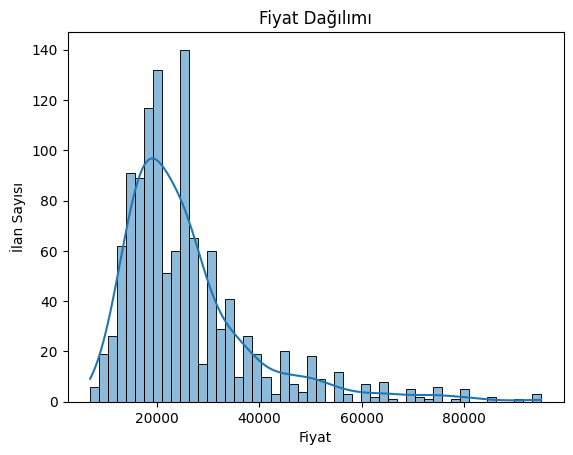

In [ ]:
sns.histplot(data=df, x="Price", bins=50, kde=True)
plt.title("Fiyat Dağılımı")
plt.xlabel("Fiyat")
plt.ylabel("İlan Sayısı")
plt.show()

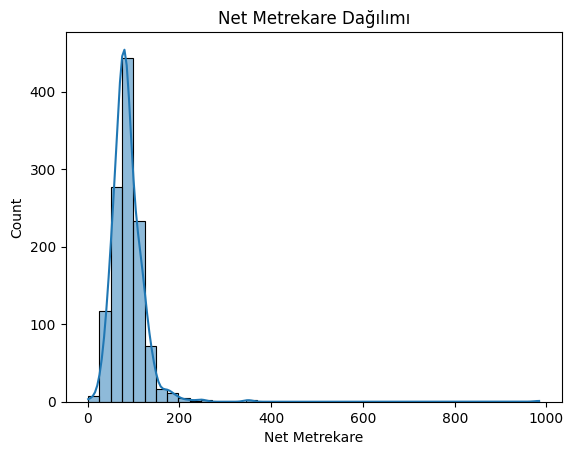

In [ ]:
sns.histplot(data=df, x="Net Metrekare", bins=40, kde=True)
plt.title("Net Metrekare Dağılımı")
plt.show()

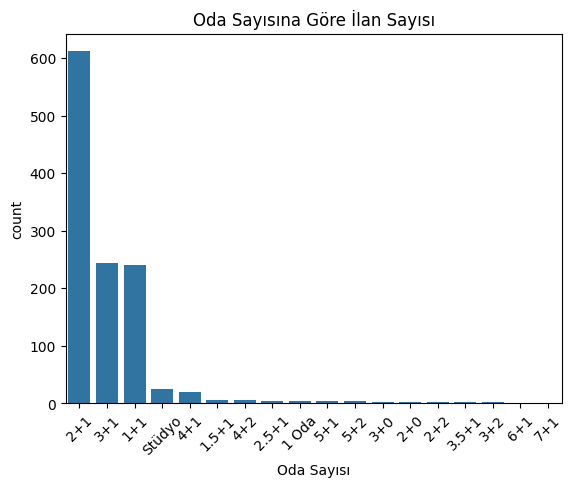

In [ ]:
sns.countplot(data=df, x="Oda Sayısı", order=df["Oda Sayısı"].value_counts().index)
plt.title("Oda Sayısına Göre İlan Sayısı")
plt.xticks(rotation=45)
plt.show()

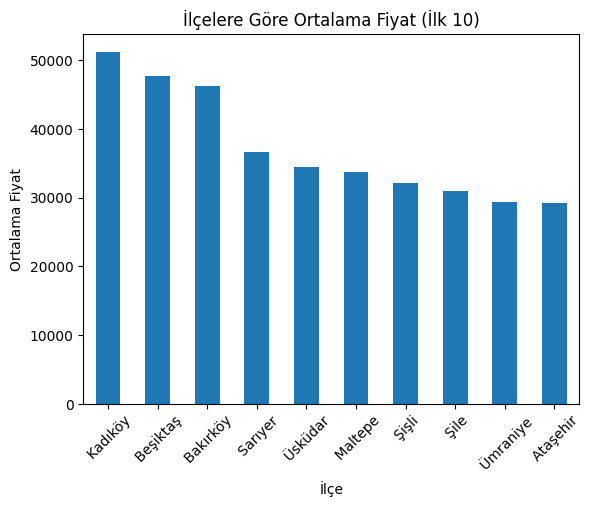

In [ ]:
ilce_avg_price = df.groupby("İlçe")["Price"].mean().sort_values(ascending=False).head(10)
ilce_avg_price.plot(kind="bar")
plt.title("İlçelere Göre Ortalama Fiyat (İlk 10)")
plt.ylabel("Ortalama Fiyat")
plt.xticks(rotation=45)
plt.show()

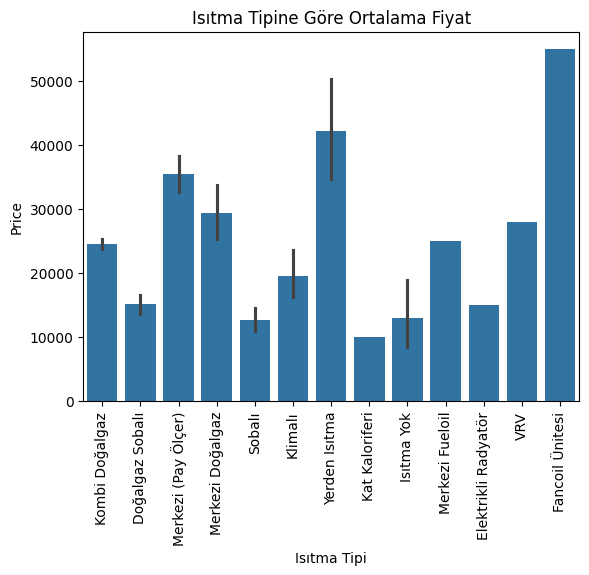

In [ ]:
sns.barplot(data=df, x="Isıtma Tipi", y="Price", estimator='mean')
plt.title("Isıtma Tipine Göre Ortalama Fiyat")
plt.xticks(rotation=90)
plt.show()

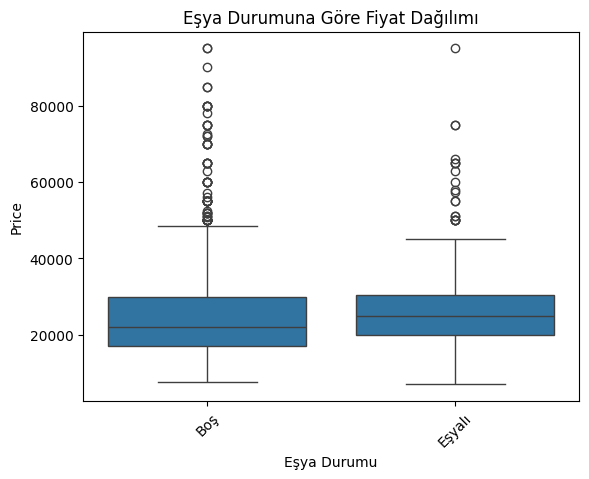

In [ ]:
sns.boxplot(data=df, x="Eşya Durumu", y="Price")
plt.title("Eşya Durumuna Göre Fiyat Dağılımı")
plt.xticks(rotation=45)
plt.show()


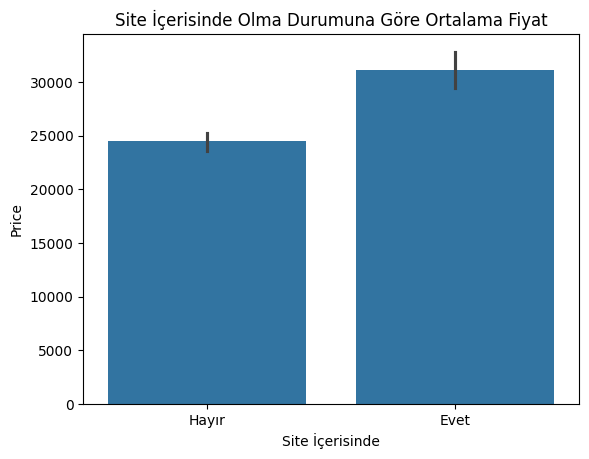

In [ ]:
sns.barplot(data=df, x="Site İçerisinde", y="Price", estimator='mean')
plt.title("Site İçerisinde Olma Durumuna Göre Ortalama Fiyat")
plt.show()


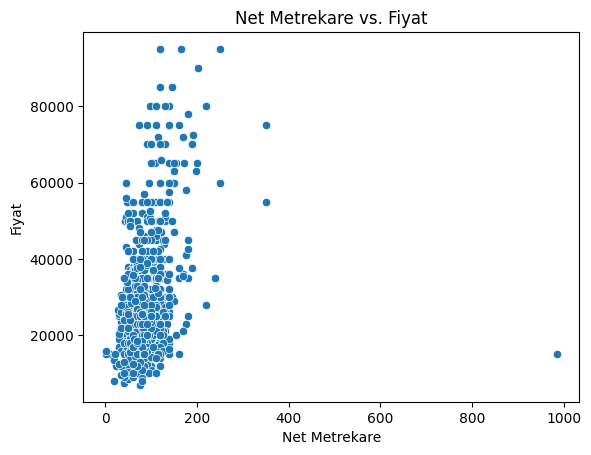

In [ ]:
sns.scatterplot(data=df, x="Net Metrekare", y="Price")
plt.title("Net Metrekare vs. Fiyat")
plt.xlabel("Net Metrekare")
plt.ylabel("Fiyat")
plt.show()


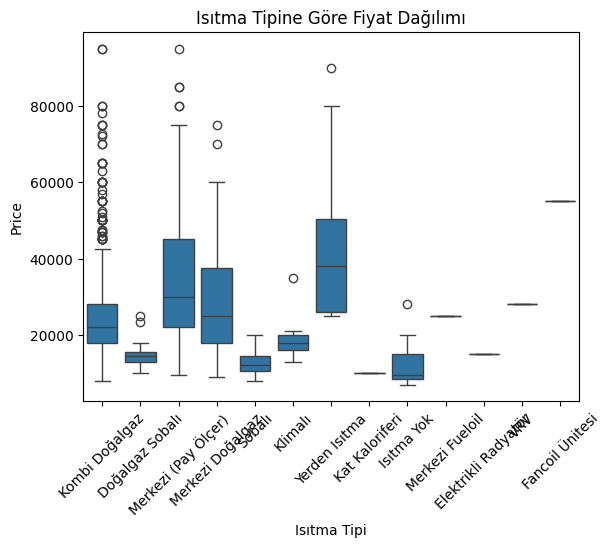

In [ ]:

sns.boxplot(data=df, x="Isıtma Tipi", y="Price")
plt.title("Isıtma Tipine Göre Fiyat Dağılımı")
plt.xticks(rotation=45)
plt.show()

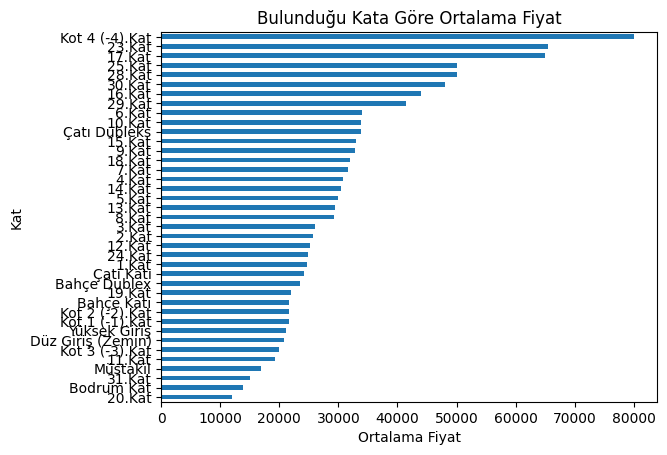

In [ ]:
kat_fiyat = df.groupby("Bulunduğu Kat")["Price"].mean().sort_values()
kat_fiyat.plot(kind='barh')
plt.title("Bulunduğu Kata Göre Ortalama Fiyat")
plt.xlabel("Ortalama Fiyat")
plt.ylabel("Kat")
plt.show()

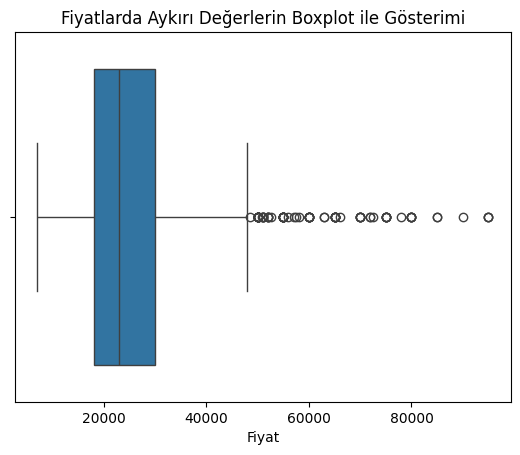

In [ ]:
sns.boxplot(x=df["Price"])
plt.title("Fiyatlarda Aykırı Değerlerin Boxplot ile Gösterimi")
plt.xlabel("Fiyat")
plt.show()

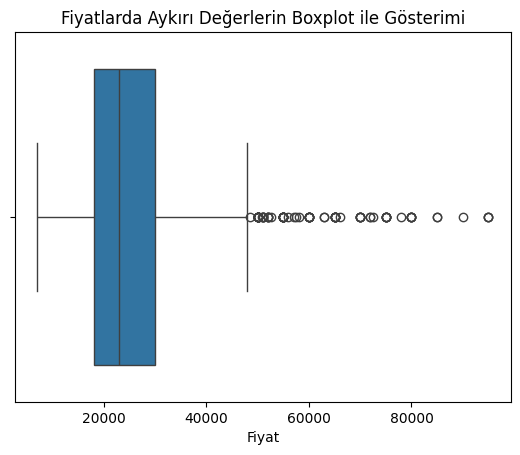

In [ ]:
sns.boxplot(x=df["Price"])
plt.title("Fiyatlarda Aykırı Değerlerin Boxplot ile Gösterimi")
plt.xlabel("Fiyat")
plt.show()

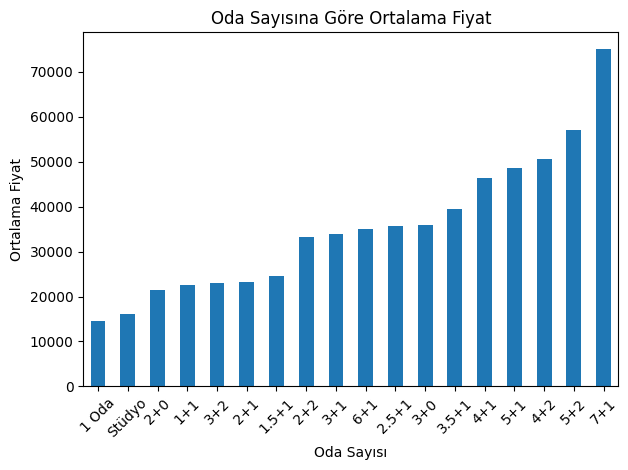

In [ ]:
oda_fiyat = df.groupby("Oda Sayısı")["Price"].mean().sort_values()

oda_fiyat.plot(kind="bar")
plt.title("Oda Sayısına Göre Ortalama Fiyat")
plt.xlabel("Oda Sayısı")
plt.ylabel("Ortalama Fiyat")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df.groupby("Oda Sayısı")["Price"].mean().sort_values()

,Price
Oda Sayısı,
1 Oda,14600.00
Stüdyo,16100.00
2+0,21500.00
1+1,22528.95
3+2,23000.00
2+1,23161.84
1.5+1,24500.00
2+2,33166.67
3+1,33995.71


In [ ]:
df["Oda Sayısı"].value_counts()

,count
Oda Sayısı,
2+1,612
3+1,245
1+1,240
Stüdyo,25
4+1,20
1.5+1,6
4+2,6
2.5+1,5
1 Oda,5


In [ ]:
df.drop("İlan Numarası", axis=1, inplace=True)

In [ ]:
df.describe()

,Unnamed: 0,Net Metrekare,Binanın Yaşı,Binanın Kat Sayısı,Balkon Sayısı,WC Sayısı,Price,İlandan sonra Geçen Gün
count,1188.00,1188.00,1188.00,1188.00,1188.00,1188.00,1188.00,1188.00
mean,598.26,87.19,11.61,6.65,0.21,1.05,26026.81,5.75
std,346.38,41.16,8.10,5.49,0.50,0.26,13296.59,6.40
min,0.00,1.00,0.00,1.00,0.00,1.00,7000.00,-1.00
25%,298.75,70.00,5.00,4.00,0.00,1.00,18000.00,0.00
50%,597.50,80.00,11.00,5.00,0.00,1.00,23000.00,3.00
75%,899.25,100.00,21.00,6.00,0.00,1.00,30000.00,10.00
max,1199.00,984.00,21.00,41.00,3.00,5.00,95000.00,95.00


In [ ]:
corr = df.corr(numeric_only=True)

In [ ]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['Unnamed: 0', 'Tipi', 'Net Metrekare', 'Oda Sayısı', 'Binanın Yaşı',
       'Bulunduğu Kat', 'Binanın Kat Sayısı', 'Isıtma Tipi', 'Tapu Durumu',
       'Site İçerisinde', 'Banyo Sayısı', 'Balkon Sayısı', 'Balkon Tipi',
       'WC Sayısı', 'Price', 'Eşya Durumu', 'İlandan sonra Geçen Gün', 'İlçe',
       'Mahalle'],
      dtype='object')>

<Axes: >

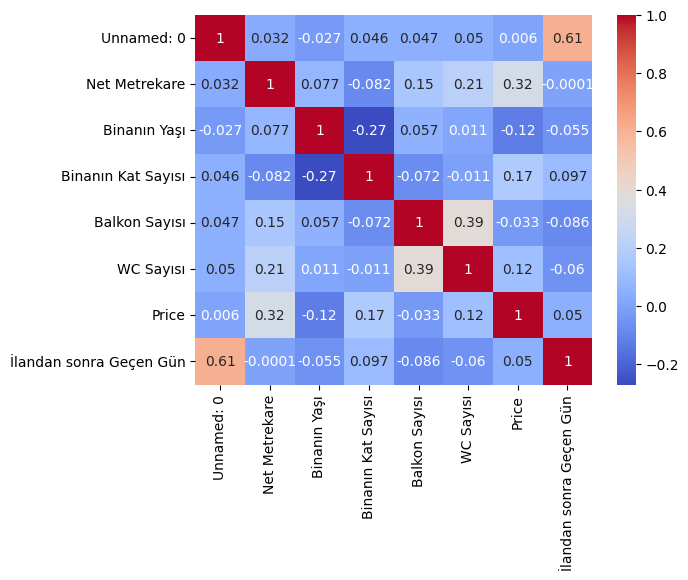

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

##### Label encoding ve deep learning için veri yetersiz olduğu için sentetik veri üretiyoruz

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Tipi,0
Net Metrekare,0
Oda Sayısı,0
Binanın Yaşı,0
Bulunduğu Kat,0
Binanın Kat Sayısı,0
Isıtma Tipi,0
Tapu Durumu,0
Site İçerisinde,0


In [ ]:
df.shape

(1188, 19)

In [ ]:
# Deep Learning Modeli için veri yetersiz olduğu için mevcut dataFrame uygun olacak şekilde yeni veriler üretiyoruz
import pandas as pd
import numpy as np


numeric_cols = ['Net Metrekare', 'Binanın Yaşı',
                'Banyo Sayısı', 'Balkon Sayısı', 'WC Sayısı', 'Price']

# Dönüştürme
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Tipi,0
Net Metrekare,0
Oda Sayısı,0
Binanın Yaşı,0
Bulunduğu Kat,0
Binanın Kat Sayısı,0
Isıtma Tipi,0
Tapu Durumu,0
Site İçerisinde,0


In [ ]:
# numeric_cols sütunlarında NaN içeren satırları silelim
df.dropna(subset=numeric_cols, inplace=True)

In [ ]:

n_augments = 2

noise_settings = {
    'Net Metrekare': 5,
    'Binanın Yaşı': 1,
    'Banyo Sayısı': 0.1,
    'Balkon Sayısı': 0.1,
    'WC Sayısı': 0.1,
    'Price': 0.05  # Price için %5
}

augmented_rows = []

for idx, row in df.iterrows():
    for i in range(n_augments):
        new_row = row.copy()
        for col in numeric_cols:
            if col == 'Price':
                noise = np.random.normal(0, noise_settings[col] * row[col])
            else:
                noise = np.random.normal(0, noise_settings[col])
            new_row[col] = row[col] + noise

            # tam sayı alması gerek sütunları yuvarlayalım
            if col in ['Banyo Sayısı', 'Balkon Sayısı', 'WC Sayısı']:
                new_row[col] = int(round(new_row[col]))
        augmented_rows.append(new_row)

# Augmented verileri DataFrame'e dönüştür
df_augmented = pd.DataFrame(augmented_rows)

# Eski ve yeni verileri birleştiriyoruz
df = pd.concat([df, df_augmented], ignore_index=True)

# Sonuç
print("Yapay üretilen veri sayısı:", df_augmented.shape[0])
print("Toplam veri sayısı:", df.shape[0])



Yapay üretilen veri sayısı: 2372
Toplam veri sayısı: 3558


### Modelling

In [ ]:
x=df.drop("Price", axis=1)
y=df[["Price"]]

In [ ]:
# One-hot Coding
x= pd.get_dummies(x, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

#### Linear Regression

In [ ]:
LR = LinearRegression()
LR.fit(x_train, y_train)
LR_pred = LR.predict(x_test)

# Performans metrikleri
lr_mse = mean_squared_error(y_test, LR_pred)
lr_r2 = r2_score(y_test, LR_pred)

print("=== Linear Regression ===")
print(f"MSE: {lr_mse:.2f}")
print(f"R^2: {lr_r2:.4f}\n")

=== Linear Regression ===
MSE: 28744241.35
R^2: 0.8458



### Lasso

In [ ]:
L = Lasso(random_state=42)
L.fit(x_train, y_train)
L_pred = L.predict(x_test)

# Performans metrikleri
lasso_mse = mean_squared_error(y_test, L_pred)
lasso_r2 = r2_score(y_test, L_pred)

print("=== Lasso ===")
print(f"MSE: {lasso_mse:.2f}")
print(f"R^2: {lasso_r2:.4f}\n")

=== Lasso ===
MSE: 29764572.85
R^2: 0.8403



### Ridge

In [ ]:
R = Ridge(random_state=42)
R.fit(x_train, y_train)
R_pred = R.predict(x_test)

# Performans metrikleri
R_mse = mean_squared_error(y_test, R_pred)
R_r2 = r2_score(y_test, R_pred)

print("=== Ridge ===")
print(f"MSE: {R_mse:.2f}")
print(f"R^2: {R_r2:.4f}\n")

=== Ridge ===
MSE: 31560189.93
R^2: 0.8307



### ElasticNet

In [ ]:
EN = ElasticNet(random_state=42)
EN.fit(x_train, y_train)
EN_pred = EN.predict(x_test)

# Performans metrikleri
EN_mse = mean_squared_error(y_test, LR_pred)
EN_r2 = r2_score(y_test, EN_pred)

print("=== ElasticNet ===")
print(f"MSE: {EN_mse:.2f}")
print(f"R^2: {EN_r2:.4f}\n")

=== ElasticNet ===
MSE: 28744241.35
R^2: 0.3174



### XGBRegressor

In [ ]:
xgb = XGBRegressor(random_state=42)
xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)

# Performans metrikleri
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("=== XGBRegressor ===")
print(f"MSE: {xgb_mse:.2f}")
print(f"R^2: {xgb_r2:.4f}\n")

=== XGBRegressor ===
MSE: 11178981.00
R^2: 0.9400



### Gradient Boosting

In [ ]:
GB = GradientBoostingRegressor(random_state=42)
GB.fit(x_train, y_train)
GB_pred = GB.predict(x_test)

# Performans metrikleri
GB_mse = mean_squared_error(y_test, GB_pred)
GB_r2 = r2_score(y_test, GB_pred)

print("=== Gradient Boosting ===")
print(f"MSE: {GB_mse:.2f}")
print(f"R^2: {GB_r2:.4f}\n")

=== Gradient Boosting ===
MSE: 48514152.49
R^2: 0.7397



### Random Forest

In [ ]:
RF = RandomForestRegressor(n_estimators=100, random_state=42)
RF.fit(x_train, y_train)
RF_pred = RF.predict(x_test)

# Performans metrikleri
RF_mse = mean_squared_error(y_test, RF_pred)
RF_r2 = r2_score(y_test, RF_pred)

print("=== Random Forest ===")
print(f"MSE: {RF_mse:.2f}")
print(f"R^2: {RF_r2:.4f}\n")

=== Random Forest ===
MSE: 11158200.51
R^2: 0.9401

